In [1]:

# Cell 1 — Imports
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

FIG = Path("../reports/figures")
print("Ready ✓")

Ready ✓


In [2]:
# Cell 2 — Load processed data
train = pd.read_csv("../data/processed/train_processed.csv")
test  = pd.read_csv("../data/processed/test_processed.csv")

X_train = train['review_clean']
y_train = train['sentiment']
X_test  = test['review_clean']
y_test  = test['sentiment']

print(f"Train: {len(X_train):,}")
print(f"Test : {len(X_test):,}")
print(f"Classes: {y_train.unique()}")

Train: 161,297
Test : 53,766
Classes: ['positive' 'neutral' 'negative']


In [3]:
# Cell 3 — TF-IDF Vectorization
print("TF-IDF vectorizing...")
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.95,
    strip_accents='unicode',
    sublinear_tf=True
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Feature matrix: {X_train_tfidf.shape}")

TF-IDF vectorizing...
Feature matrix: (161297, 50000)


In [4]:
# Cell 4 — Logistic Regression Baseline
print("Training Logistic Regression...")
lr = LogisticRegression(
    max_iter=1000,
    C=1.0,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
lr.fit(X_train_tfidf, y_train)
y_pred = lr.predict(X_test_tfidf)

print("\n" + "="*55)
print("BASELINE — TF-IDF + Logistic Regression")
print("="*55)
print(classification_report(y_test, y_pred,
      target_names=['negative','neutral','positive']))

Training Logistic Regression...

BASELINE — TF-IDF + Logistic Regression
              precision    recall  f1-score   support

    negative       0.75      0.80      0.77     11838
     neutral       0.43      0.66      0.52      6488
    positive       0.94      0.83      0.88     35440

    accuracy                           0.80     53766
   macro avg       0.71      0.76      0.73     53766
weighted avg       0.84      0.80      0.82     53766



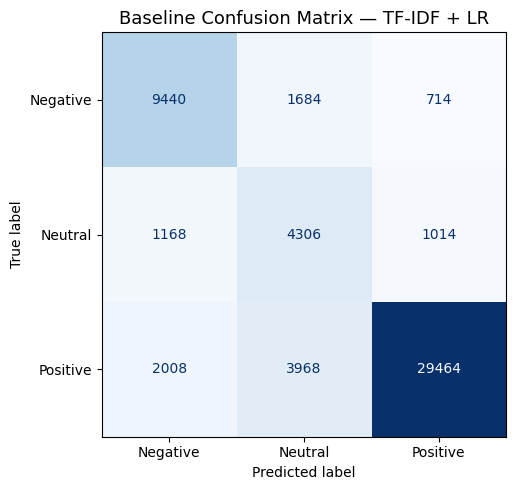

Saved ✓


In [5]:
# Cell 5 — Confusion Matrix
fig, ax = plt.subplots(figsize=(7, 5))
cm = confusion_matrix(y_test, y_pred,
                      labels=['negative','neutral','positive'])
disp = ConfusionMatrixDisplay(cm,
       display_labels=['Negative','Neutral','Positive'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title("Baseline Confusion Matrix — TF-IDF + LR", fontsize=13)
plt.tight_layout()
plt.savefig(FIG / "03_baseline_confusion.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ✓")

Top words per sentiment class:

NEGATIVE: worse, not recommend, not worth, disappointed, worst, no improvement, useless, never, horrible, no relief, wouldn recommend, never again, nothing for, not, terrible
NEUTRAL: however, but, was great, was effective, rating, hoping, but gave, not happy, not sure, yet, to love, work well, helps with, lazy, but do
POSITIVE: love, amazing, miracle, great, best, love it, saved, love this, works, years, wonderful, no side, highly recommend, excellent, life


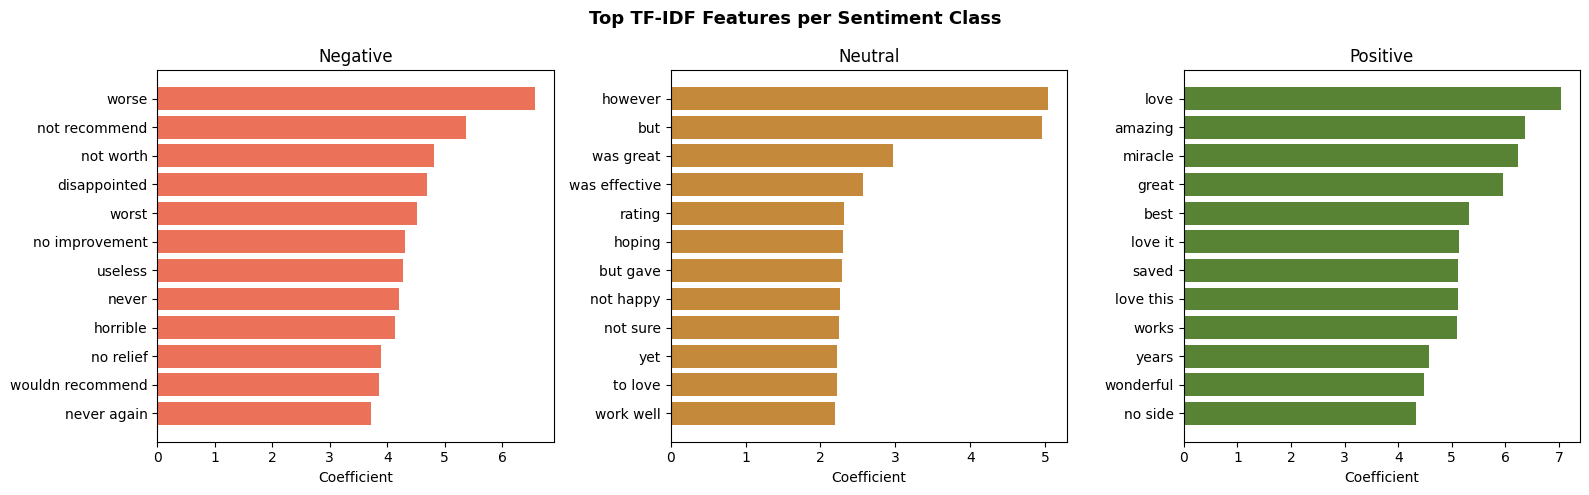

Saved ✓


In [6]:
# Cell 6 — Top TF-IDF features per class
print("Top words per sentiment class:\n")
feature_names = tfidf.get_feature_names_out()
for i, class_name in enumerate(lr.classes_):
    top_idx = lr.coef_[i].argsort()[-15:][::-1]
    top_words = [feature_names[j] for j in top_idx]
    print(f"{class_name.upper()}: {', '.join(top_words)}")

# Plot top features
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Top TF-IDF Features per Sentiment Class",
             fontsize=13, fontweight='bold')
colors = {'negative':'#E8593C','neutral':'#BA7517','positive':'#3B6D11'}

for ax, class_name in zip(axes, lr.classes_):
    i = list(lr.classes_).index(class_name)
    top_idx   = lr.coef_[i].argsort()[-12:]
    top_words = [feature_names[j] for j in top_idx]
    top_vals  = lr.coef_[i][top_idx]
    ax.barh(top_words, top_vals, color=colors[class_name], alpha=0.85)
    ax.set_title(f"{class_name.capitalize()}", fontsize=12)
    ax.set_xlabel("Coefficient")

plt.tight_layout()
plt.savefig(FIG / "04_tfidf_features.png", bbox_inches='tight', dpi=150)
plt.show()
print("Saved ✓")

In [7]:
# Cell 7 — Baseline Summary
from sklearn.metrics import accuracy_score, f1_score

acc = accuracy_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred, average='weighted')

print("="*55)
print("BASELINE RESULTS (paper ke liye)")
print("="*55)
print(f"Accuracy         : {acc*100:.2f}%")
print(f"F1 (weighted)    : {f1:.4f}")
print(f"Model            : TF-IDF (50k features, bigrams)")
print(f"Classifier       : Logistic Regression (balanced)")
print("="*55)
print("\nNext → 03_biobert.ipynb (main model)")

BASELINE RESULTS (paper ke liye)
Accuracy         : 80.37%
F1 (weighted)    : 0.8161
Model            : TF-IDF (50k features, bigrams)
Classifier       : Logistic Regression (balanced)

Next → 03_biobert.ipynb (main model)
